Topic : **Breast Cancer Prediction using Decision Tree Classifier**

Student Name : FATIN SYAZANA BINTI AZHAR

Matrix Number : S23B0125

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [16]:
# ==========================================
# 1. LOAD DATASET & BASIC INSPECTION
# ==========================================
# Load the dataset from the specified file path
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/breastcancerprediction.csv')

# Display the first 5 rows of the data
print("--- Top 5 Rows of Data ---")
print(df.head())

# Display the data structure, column types, and info
print("\n--- Data Structure Information ---")
print(df.info())

--- Top 5 Rows of Data ---
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_wo

In [17]:
# ==========================================
# 2. DATA CLEANING
# ==========================================
print("\n=== DATA CLEANING PHASE ===")

# Check for missing values in each column
print("Total missing values:")
print(df.isnull().sum().sum())

# Check for duplicate rows in the dataset
print(f"Total duplicate rows: {df.duplicated().sum()}")

# Drop columns that are not useful for prediction
# 'id' does not affect the outcome, and 'Unnamed: 32' is empty
columns_to_drop = ['id', 'Unnamed: 32']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Convert categorical labels to numerical values (Malignant = 1, Benign = 0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
print("\nData Cleaning Completed!")


=== DATA CLEANING PHASE ===
Total missing values:
569
Total duplicate rows: 0

Data Cleaning Completed!



=== EXPLORATORY DATA ANALYSIS (EDA) PHASE ===


/tmp/ipykernel_921/1860686900.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='Set2')


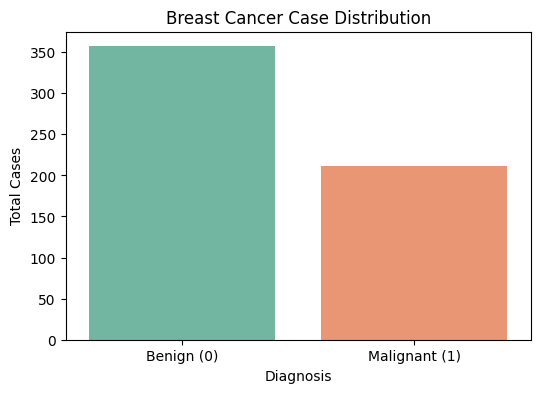

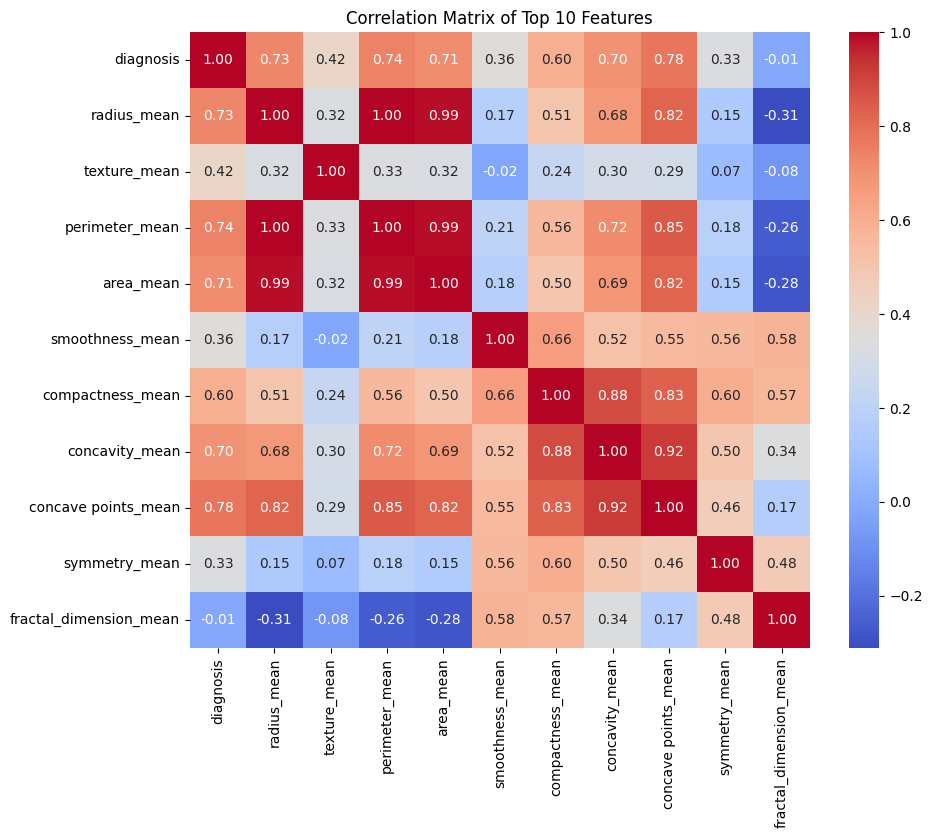

In [22]:
# ==========================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
print("\n=== EXPLORATORY DATA ANALYSIS (EDA) PHASE ===")

# Graph A: Plot the distribution of the target variable (Malignant vs Benign)
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df, palette='Set2')
plt.xticks([0, 1], ['Benign (0)', 'Malignant (1)'])
plt.title('Breast Cancer Case Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Total Cases')
plt.show()

# Graph B: Plot a correlation matrix heatmap
# Select only the first 10 features to keep the visual simple and clean
plt.figure(figsize=(10, 8))
features_sampled = df.iloc[:, :11]
correlation_matrix = features_sampled.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
print("\n")
plt.title('Correlation Matrix of Top 10 Features')
plt.show()

In [19]:
# ==========================================
# 4. DATA PREPROCESSING
# ==========================================
# Separate the features (X) and the target variable (y)
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Split the dataset into 80% Training set and 20% Testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


=== MODEL TRAINING & EVALUATION PHASE ===
Decision Tree Model Accuracy: 94.74%

Full Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      0.97      0.96        71
   Malignant       0.95      0.91      0.93        43

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



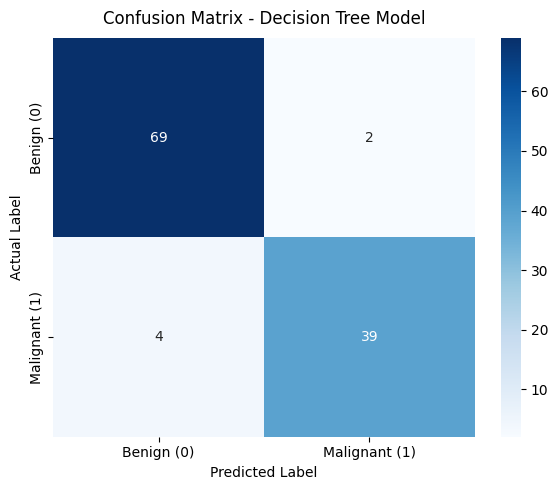

In [20]:
# ==========================================
# 5. MODEL BUILDING & EVALUATION (Decision Tree)
# ==========================================
print("\n=== MODEL TRAINING & EVALUATION PHASE ===")

# Initialize the Decision Tree model with max_depth=3 to avoid overfitting
model_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
model_dt.fit(X_train, y_train)

# Make predictions on the test dataset
y_pred = model_dt.predict(X_test)

# Display performance metrics and accuracy results
print(f"Decision Tree Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

# Generate the numerical confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a clear heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])

# Add labels and formatting to the graph
plt.title('Confusion Matrix - Decision Tree Model', fontsize=12, pad=10)
plt.ylabel('Actual Label', fontsize=10)
plt.xlabel('Predicted Label', fontsize=10)
plt.tight_layout()
plt.show()

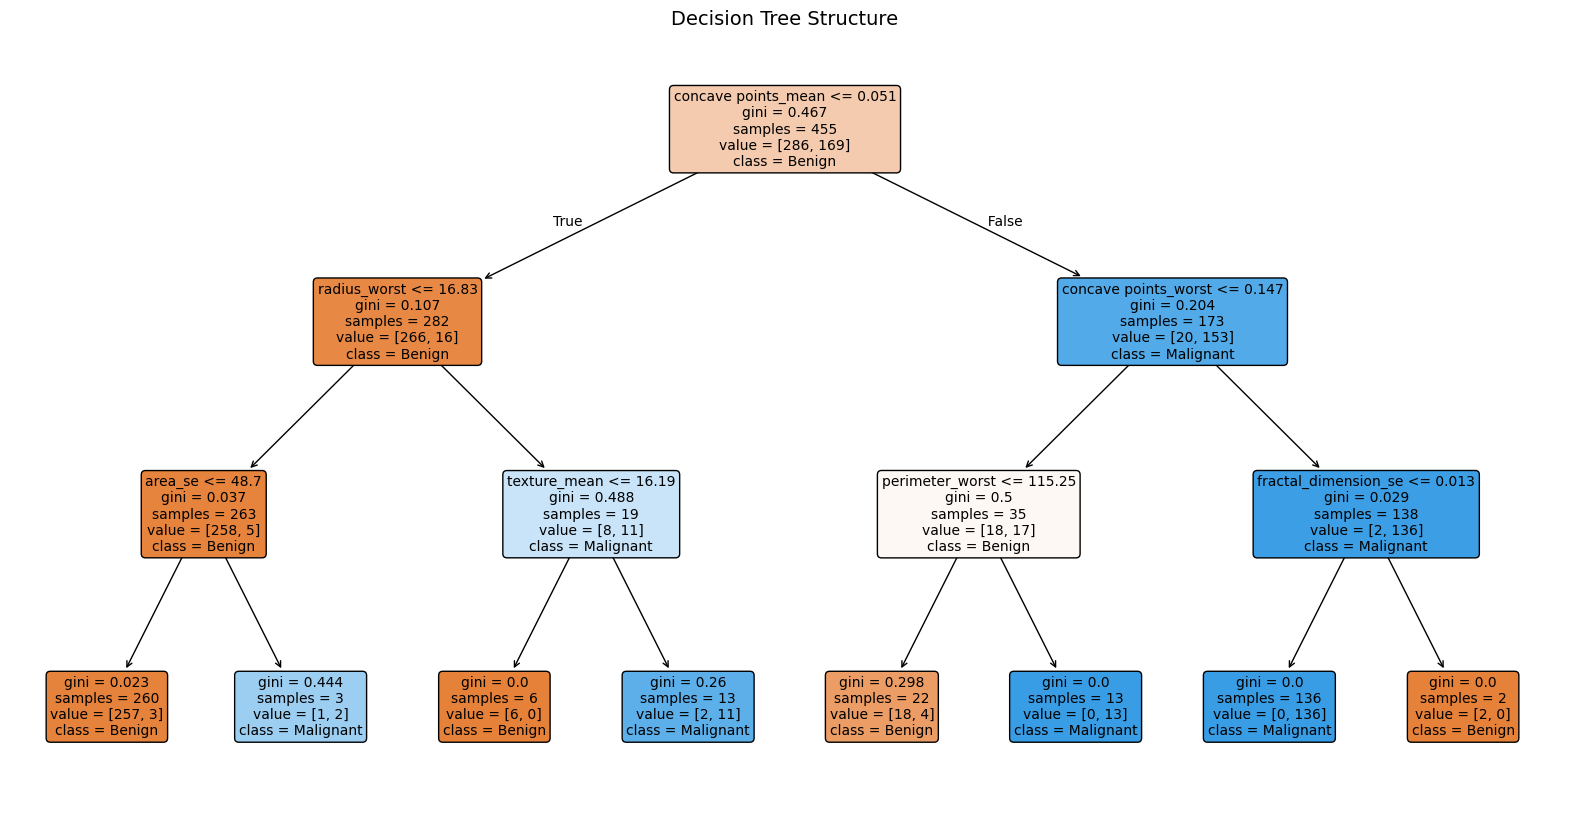

In [21]:
# ==========================================
# 6. DECISION TREE VISUALIZATION
# ==========================================
# Plot and display the actual structure of the decision tree
plt.figure(figsize=(20, 10))
plot_tree(model_dt,
          feature_names=X.columns,
          class_names=['Benign', 'Malignant'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Structure", fontsize=14)
plt.show()